In [1]:
import pandas as pd
from bromo.evaluations.tka import eval_q1_scores, eval_q1_dataframes,eval_curve_list
from bromo.evaluations.utils import avg_fwdrev_score, prepare_dfs


### 1. Some preprocessing for PREGO and PeptideRanger outputs

In [2]:
######### PREGO Yeast #########
prego_yeast = pd.read_csv('../../Datasets/external_baselines/yeast/prego/prego_output_UP000002311_559292.txt', sep='\t',header=None)
prego_yeast.columns = ['uniprot_id','rank','peptide','prego_score']
prego_yeast['protein'] = prego_yeast['uniprot_id'].str.split('|').str[1]
prego_yeast.drop(columns=['uniprot_id','rank'],inplace=True)


######### PeptideRanger Yeast #########
peptideranger_yeast = pd.read_csv('../../Datasets/external_baselines/yeast/peptideranger/UP000002311_559292_prioritized_peptides.tsv',sep='\t')
peptideranger_yeast.drop(columns=['symbol','missed_cleavages','start','end','size'],inplace=True)
peptideranger_yeast = peptideranger_yeast.rename(columns={'uniprot':'protein','sequence':'peptide'})


### 2. TKA plots for: yeast-astral

In [3]:
bromo_preds_path_astral = '../../Datasets/inference/yeast-astral/full_predictions.tsv'
bromo_preds_astral = prepare_dfs(bromo_preds_path_astral)
bromo_uniquepair_astral = avg_fwdrev_score(bromo_preds_astral)


In [4]:
astral_trues, astral_preds = eval_q1_dataframes(bromo_uniquepair_astral, 5)
astral_ranks = astral_trues.merge(astral_preds, on=['protein','peptide','pred_wins','true_wins'])
astral_ranks['peptide_sequence'] = astral_ranks.peptide.str.split('|').str[0].tolist()
astral_ranks = astral_ranks.drop_duplicates('peptide_sequence')
astral_ranks.drop(columns=['peptide'],inplace=True)
astral_ranks.rename(columns={'peptide_sequence':'peptide'},inplace=True)

In [5]:
merged = prego_yeast.merge(astral_ranks, on=['protein','peptide'])
merged = merged.merge(peptideranger_yeast, on=['protein','peptide'])

In [6]:
results = eval_q1_scores(
    merged,
    topk=5,
    true_col="sort_columns_true",
    pred_cols=["sort_columns_pred", "prego_score", "RF_score"],
)

q1_dict_pred        = results["sort_columns_pred"]
q1_dict_prego       = results["prego_score"]
q1_dict_peptideranger = results["RF_score"]

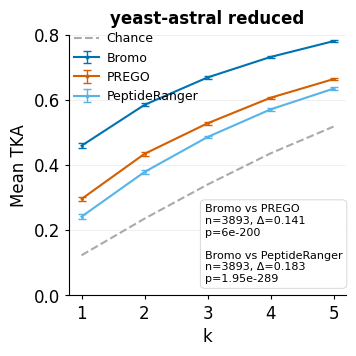

In [7]:
curve_dicts_q1_astral = eval_curve_list(
    dfs=None,
    topk=5, metric="q1", labels=['Bromo','PREGO','PeptideRanger'],
    title='yeast-astral reduced',
    save_path='./fig2d_astral_maxpep.pdf',
    curve_dicts=[q1_dict_pred, q1_dict_prego, q1_dict_peptideranger],
    ttest_loc=(0.49, 0.35),
    ylim=(0, 0.8),
    legend_loc=(0.0005, 0.72),
    legend_fs=9,
    ttest_text_fs=8,
    ylabel='Mean TKA',
    colors=["#0072B2","#D55E00","#56B4E9"],
    show_chance=True,
    chance_df=merged,
    error_bars = True,
    band='sem',
    markersize=1,    # default 4
    linewidth=1.5
)

### 3. TKA plots for: yeast-lumos

In [8]:
bromo_preds_path_lumos = '../../Datasets/inference/yeast-lumos/full_predictions.tsv'
bromo_preds_lumos = prepare_dfs(bromo_preds_path_lumos)
bromo_uniquepair_lumos = avg_fwdrev_score(bromo_preds_lumos)


In [9]:
lumos_trues, lumos_preds = eval_q1_dataframes(bromo_uniquepair_lumos, 5)
lumos_ranks = lumos_trues.merge(lumos_preds, on=['protein','peptide','pred_wins','true_wins'])
lumos_ranks['peptide_sequence'] = lumos_ranks.peptide.str.split('|').str[0].tolist()
lumos_ranks = lumos_ranks.drop_duplicates('peptide_sequence')
lumos_ranks.drop(columns=['peptide'],inplace=True)
lumos_ranks.rename(columns={'peptide_sequence':'peptide'},inplace=True)

In [10]:
merged = prego_yeast.merge(lumos_ranks, on=['protein','peptide'])
merged = merged.merge(peptideranger_yeast, on=['protein','peptide'])

In [11]:
results = eval_q1_scores(
    merged,
    topk=5,
    true_col="sort_columns_true",
    pred_cols=["sort_columns_pred", "prego_score", "RF_score"],
)

q1_dict_pred        = results["sort_columns_pred"]
q1_dict_prego       = results["prego_score"]
q1_dict_peptideranger = results["RF_score"]

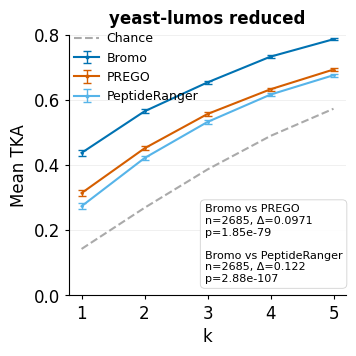

In [12]:
curve_dicts_q1_lumos = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo','PREGO','PeptideRanger'],
    title = 'yeast-lumos reduced',
    save_path = './fig2f_lumos_maxpep.pdf',
    curve_dicts = [q1_dict_pred, q1_dict_prego, q1_dict_peptideranger],
    ttest_loc=(0.49, 0.35),
    ylim = (0,0.8),
    legend_fs = 9,
    ttest_text_fs = 8,
    legend_loc=(0.0005, 0.72),
    ylabel = 'Mean TKA',
    colors = ["#0072B2","#D55E00","#56B4E9"],
    show_chance=True,
    chance_df=merged,
    error_bars = True,
    band='sem',
    markersize=1,    # default 4
    linewidth=1.5
    )

### 4. TKA plots for: yeast-exploris

In [13]:
bromo_preds_path_exploris = '../../Datasets/inference/yeast-exploris/full_predictions.tsv'
bromo_preds_exploris = prepare_dfs(bromo_preds_path_exploris)
bromo_uniquepair_exploris = avg_fwdrev_score(bromo_preds_exploris)

In [14]:
exploris_trues, exploris_preds = eval_q1_dataframes(bromo_uniquepair_exploris, 5)
exploris_ranks = exploris_trues.merge(exploris_preds, on=['protein','peptide','pred_wins','true_wins'])
exploris_ranks['peptide_sequence'] = exploris_ranks.peptide.str.split('|').str[0].tolist()
exploris_ranks = exploris_ranks.drop_duplicates('peptide_sequence')
exploris_ranks.drop(columns=['peptide'],inplace=True)
exploris_ranks.rename(columns={'peptide_sequence':'peptide'},inplace=True)

In [15]:
merged = prego_yeast.merge(exploris_ranks, on=['protein','peptide'])
merged = merged.merge(peptideranger_yeast, on=['protein','peptide'])

In [16]:
results = eval_q1_scores(
    merged,
    topk=5,
    true_col="sort_columns_true",
    pred_cols=["sort_columns_pred", "prego_score", "RF_score"],
)

q1_dict_pred        = results["sort_columns_pred"]
q1_dict_prego       = results["prego_score"]
q1_dict_peptideranger = results["RF_score"]

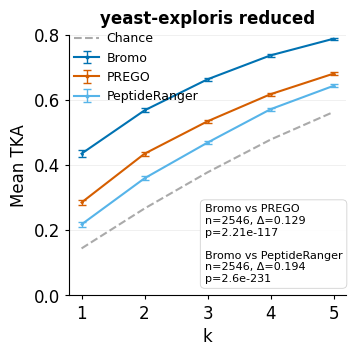

In [17]:
curve_dicts_q1_lumos = eval_curve_list(
    dfs = None,
    topk=5, metric="q1", labels=['Bromo','PREGO','PeptideRanger'],
    title = 'yeast-exploris reduced',
    save_path = './fig2e_exploris_maxpep.pdf',
    curve_dicts = [q1_dict_pred, q1_dict_prego, q1_dict_peptideranger],
    ttest_loc=(0.49, 0.35),
    ylim = (0,0.8),
    legend_fs = 9,
    ttest_text_fs = 8,
    legend_loc=(0.0005, 0.72),
    ylabel = 'Mean TKA',
    colors = ["#0072B2","#D55E00","#56B4E9"],
    show_chance=True,
    chance_df=merged,
    error_bars = True,
    band='sem',
    markersize=1,    # default 4
    linewidth=1.5
    )